In [6]:
#Winning in First Three Strokes?
import pandas as pd
ttdynamics = pd.read_csv('table_tennis_data.csv')
ttdynamics['Winning in First Three Strokes'].value_counts(normalize=True)
# 1 = Yes
# 0 = No

Winning in First Three Strokes
1    0.593333
0    0.406667
Name: proportion, dtype: float64

In [2]:
#Average rally duration(Since this is not in the dataset, I will calculate it by assuming that shortrally are around 2.3 strokes and longrally are around 5.3 strokes)
# short rally = 2.3 because it is unlikely that a rally will end in either serve or serve recieve
# long rally = 5.3 because it is 4 strokes and above but it is unlikely to go beyond 6 strokes
avg = (0.593333 * 2.3) + (0.486667 * 5.3)
print(avg)

3.944001


In [3]:
#Topspin or Backspin?
ttdynamics['Topspin/Backspin Indicator'].value_counts(normalize=True)
# 1 = Topspin
# 0 = Backspin

Topspin/Backspin Indicator
1    0.657333
0    0.342667
Name: proportion, dtype: float64

In [4]:
#Forehand or Backhand?
ttdynamics['Forehand/Backhand Indicator'].value_counts(normalize=True)
# 1 = Forehand
# 0 = Backhand

Forehand/Backhand Indicator
1    0.657333
0    0.342667
Name: proportion, dtype: float64

In [5]:
#Average X Y Position
positionX = ttdynamics['X'].mean()
positionY = ttdynamics['Y'].mean()
print(f"Average Position - X: {positionX}, Y: {positionY}")

Average Position - X: 109.534, Y: 60.56466666666667


In [9]:
#Player Win Rates(out of the total matches)(of the second dataset)
monthtt = pd.read_csv('Setka.csv')
monthtt['p1won'] = monthtt['Sets_P1'] == 3
monthtt['p2won'] = monthtt['Sets_P2'] == 3
dicwon = {}
diclost = {}
for i in range(len(monthtt)):
    if monthtt['p1won'].iloc[i] == True:
        if monthtt['Player1'].iloc[i] not in dicwon:
            dicwon[monthtt['Player1'].iloc[i]] = 1
        else:
            dicwon[monthtt['Player1'].iloc[i]] += 1
        if monthtt['Player2'].iloc[i] not in diclost:
            diclost[monthtt['Player2'].iloc[i]] = 1
        else:
            diclost[monthtt['Player2'].iloc[i]] += 1
    else:
        if monthtt['Player1'].iloc[i] not in diclost:
            diclost[monthtt['Player1'].iloc[i]] = 1
        else:
            diclost[monthtt['Player1'].iloc[i]] += 1
        if monthtt['Player2'].iloc[i] not in dicwon:
            dicwon[monthtt['Player2'].iloc[i]] = 1
        else:
            dicwon[monthtt['Player2'].iloc[i]] += 1
winrate = {}
for player in dicwon:
    if player not in diclost:
        diclost[player] = 0
    elif player not in dicwon:
        dicwon[player] = 0
    wrate = dicwon[player] / (diclost[player] + dicwon[player])
    winrate[player] = wrate
print(winrate)

{'Marchuk M.': 0.40625, 'Sachuk S.': 0.6571428571428571, 'Samofal Y.': 0.65625, 'Kyilo V.': 0.4520547945205479, 'Polysynskyi M.': 0.41333333333333333, 'Diachenko M.': 0.4810126582278481, 'Balakiriev M.': 0.5, 'Hryshchenko O.': 0.5443037974683544, 'Sokolov S.': 0.6714285714285714, 'Bambutsa R.': 0.4528301886792453, 'Baday M.': 0.7428571428571429, 'Lutskyi V.': 0.4, 'Hordiichuk O.': 0.45, 'Zaitsev O.': 0.4666666666666667, 'Vons V.': 0.72, 'Nikolenko S.': 0.42857142857142855, 'Fedoryshyn I.': 0.6231884057971014, 'Stukalov V.': 0.5882352941176471, 'Mishchenko V.': 0.4897959183673469, 'Fylypiv R.': 0.6, 'Semipeadnii V.': 0.2903225806451613, 'Rak S.': 0.6344086021505376, 'Ponomarenko O.': 0.5428571428571428, 'Kolbasenko O.': 0.5714285714285714, 'Mul S.': 0.8888888888888888, 'Marko J.': 0.5, 'Cherevko R.': 0.3076923076923077, 'Kunchurov D.': 0.47619047619047616, 'Sklyarenko A.': 0.52, 'Brozek M.': 0.5909090909090909, 'Dubrovin V.': 0.6829268292682927, 'Mikus D.': 0.6428571428571429, 'Slozka M

In [2]:
df.head()

,Unnamed: 0,Date,Player1,Player2,Sets_P1,Sets_P2,P1_G1,P2_G1,P1_G2,P2_G2,P1_G3,P2_G3,P1_G4,P2_G4,P1_G5,P2_G5,HomeWinner,Day
0,1,2022-06-10 01:05:00,Marchuk M.,Polysynskyi M.,3,1,11,8,11,6,6,11,11.0,8.0,NaN,NaN,1,2022-06-10
1,2,2022-06-10 01:25:00,Sokolov S.,Sachuk S.,0,3,12,14,8,11,5,11,NaN,NaN,NaN,NaN,0,2022-06-10
2,3,2022-06-10 01:35:00,Samofal Y.,Bambutsa R.,3,1,4,11,11,5,11,6,11.0,9.0,NaN,NaN,1,2022-06-10
3,4,2022-06-10 01:55:00,Kyilo V.,Chernyshov D.,3,1,6,11,11,1,15,13,11.0,7.0,NaN,NaN,1,2022-06-10
4,5,2022-06-10 02:05:00,Polysynskyi M.,Kostiuk B.,3,0,12,10,11,9,11,6,NaN,NaN,NaN,NaN,1,2022-06-10


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = pd.read_csv('Setka.csv')

df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = df['Date'].dt.date

player_stats = []

all_players = set(df['Player1'].unique()) | set(df['Player2'].unique())

for player in all_players:
    player1_matches = df[df['Player1'] == player].copy()
    player2_matches = df[df['Player2'] == player].copy()

    player1_matches['won'] = player1_matches['HomeWinner'] == 1

    player2_matches['won'] = player2_matches['HomeWinner'] == 0

    player_matches = pd.concat([
        player1_matches[['Date', 'Day', 'won']],
        player2_matches[['Date', 'Day', 'won']]
    ])

    total_matches = len(player_matches)
    total_wins = player_matches['won'].sum()
    overall_winrate = (total_wins / total_matches * 100) if total_matches > 0 else 0

    if total_matches < 10:
        continue

    # Calculate average days between matches (FIXED LOGIC)
    # Sort all matches by date
    player_matches_sorted = player_matches.sort_values('Date').reset_index(drop=True)
    
    if len(player_matches_sorted) > 1:
        day_differences = []
        for i in range(1, len(player_matches_sorted)):
            prev_day = player_matches_sorted.loc[i-1, 'Day']
            curr_day = player_matches_sorted.loc[i, 'Day']
            diff = (pd.to_datetime(curr_day) - pd.to_datetime(prev_day)).days
            day_differences.append(diff)
        avg_days_between_matches = np.mean(day_differences)
    else:
        avg_days_between_matches = 0

    daily_stats = player_matches.groupby('Day').agg({
        'won': ['sum', 'count']
    })
    daily_stats.columns = ['wins', 'matches']
    daily_stats['winrate'] = (daily_stats['wins'] / daily_stats['matches'] * 100)
    
    if len(daily_stats) > 0:
        highest_daily_winrate = daily_stats['winrate'].max()
        lowest_daily_winrate = daily_stats['winrate'].min()
        winrate_difference = highest_daily_winrate - lowest_daily_winrate
    else:
        highest_daily_winrate = 0
        lowest_daily_winrate = 0
        winrate_difference = 0

    player_stats.append({
        'Player Name': player,
        'Total Matches': total_matches,
        'Overall Win Rate (%)': round(overall_winrate, 2),
        'Highest Daily Win Rate (%)': round(highest_daily_winrate, 2),
        'Lowest Daily Win Rate (%)': round(lowest_daily_winrate, 2),
        'Win Rate Difference (%)': round(winrate_difference, 2),
        'Avg Days Between Matches': round(avg_days_between_matches, 2)
    })

result_df = pd.DataFrame(player_stats)

result_df = result_df.sort_values('Overall Win Rate (%)', ascending=False).reset_index(drop=True)

# Set pandas display options to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(result_df)

# A dataset that shows each player's total matches, overall win rate, highest and lowest daily win rates, and the difference between highest and lowest daily win rates,
# win rate = win/total matches played on that day * 100
# highest daily win rate = highest win rate achieved by the player on any single day
# lowest daily win rate = lowest win rate achieved by the player on any single day
# Avg Days Between Matches = average number of days between EACH INDIVIDUAL match (not just between unique days)
# Example: 5 matches on Day 1, 5 matches on Day 11 = (0+0+0+0+10+0+0+0+0)/9 = 1.11 days average
# Note that only players with at least 10 matches are included in the dataset. So that the data is more reliable.

        Player Name  Total Matches  Overall Win Rate (%)  \
0         Kostyv M.             10                100.00   
1         Bouska M.             11                100.00   
2    Sokolovskyi S.             20                 95.00   
3          Bulat P.             14                 92.86   
4          Bosak D.             10                 90.00   
..              ...            ...                   ...   
447      Priadko Y.             10                 10.00   
448   Kononikhin V.             11                  9.09   
449      Mykytuk D.             14                  7.14   
450         Reva V.             20                  5.00   
451      Yamchuk V.             18                  0.00   

     Highest Daily Win Rate (%)  Lowest Daily Win Rate (%)  \
0                         100.0                      100.0   
1                         100.0                      100.0   
2                         100.0                       80.0   
3                         100.0


=== Win Rate Statistics ===
Mean Win Rate: 49.75%
Median Win Rate: 50.00%
Std Deviation: 14.78%
Min Win Rate: 0.00%
Max Win Rate: 100.00%


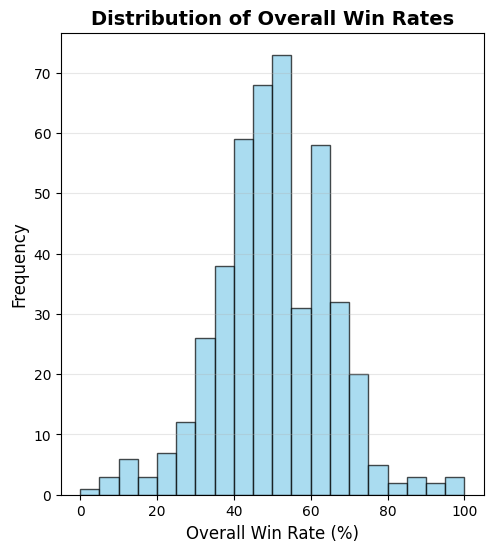

In [6]:
fig1 = plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(result_df['Overall Win Rate (%)'], bins=20, edgecolor='black', color='skyblue', alpha=0.7)
plt.xlabel('Overall Win Rate (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Overall Win Rates', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

print("\n=== Win Rate Statistics ===")
print(f"Mean Win Rate: {result_df['Overall Win Rate (%)'].mean():.2f}%")
print(f"Median Win Rate: {result_df['Overall Win Rate (%)'].median():.2f}%")
print(f"Std Deviation: {result_df['Overall Win Rate (%)'].std():.2f}%")
print(f"Min Win Rate: {result_df['Overall Win Rate (%)'].min():.2f}%")
print(f"Max Win Rate: {result_df['Overall Win Rate (%)'].max():.2f}%")

#Most players in the club have a win rate between 34.97% and 64.53% which indicates that most players' skill levels are in the middle range. Most players are neither beginners nor advanced players.

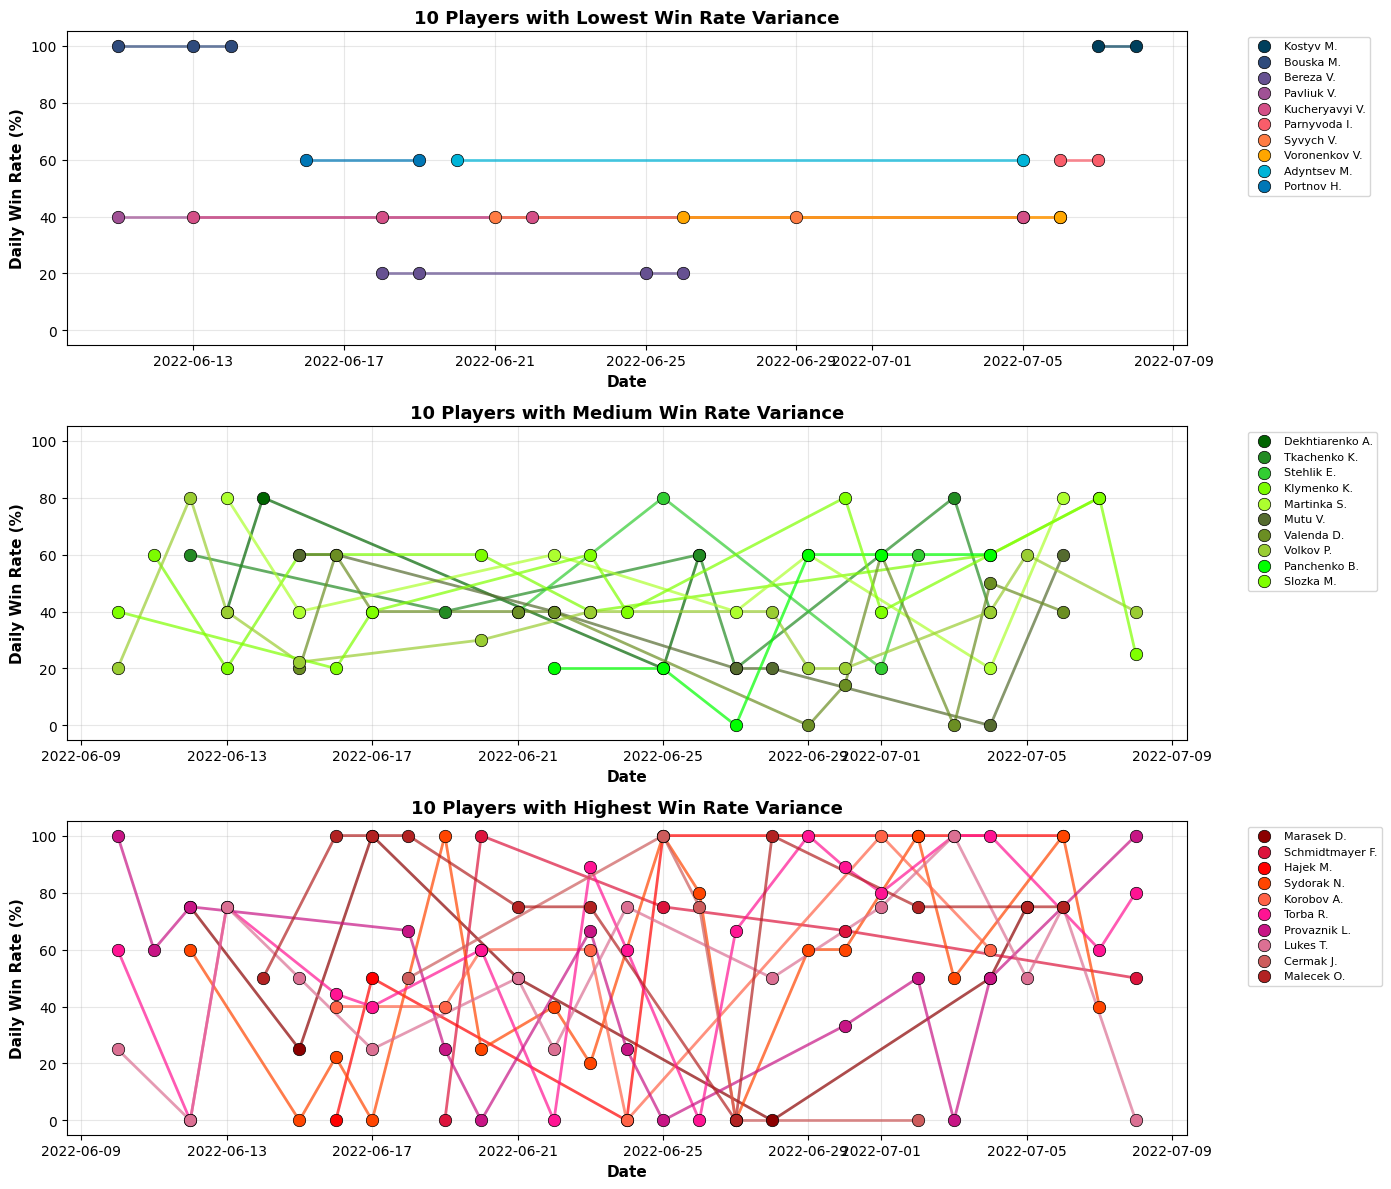

In [7]:
player_daily_data = {}

for player in result_df['Player Name']:
    player1_matches = df[df['Player1'] == player].copy()
    player2_matches = df[df['Player2'] == player].copy()
    
    player1_matches['won'] = player1_matches['HomeWinner'] == 1
    player2_matches['won'] = player2_matches['HomeWinner'] == 0
    
    player_matches = pd.concat([
        player1_matches[['Date', 'Day', 'won']],
        player2_matches[['Date', 'Day', 'won']]
    ])
    
    daily_stats = player_matches.groupby('Day').agg({
        'won': ['sum', 'count']
    })
    daily_stats.columns = ['wins', 'matches']
    daily_stats['winrate'] = (daily_stats['wins'] / daily_stats['matches'] * 100)
    daily_stats = daily_stats.reset_index()
    
    player_daily_data[player] = daily_stats

result_df_sorted = result_df.sort_values('Win Rate Difference (%)')

n_players = len(result_df_sorted)
if n_players >= 30:
    low_variance_players = result_df_sorted.head(10)['Player Name'].tolist()
    medium_variance_players = result_df_sorted.iloc[n_players//2 - 5:n_players//2 + 5]['Player Name'].tolist()
    high_variance_players = result_df_sorted.tail(10)['Player Name'].tolist()
else:
    n_per_group = n_players // 3
    low_variance_players = result_df_sorted.head(n_per_group)['Player Name'].tolist()
    medium_variance_players = result_df_sorted.iloc[n_per_group:2*n_per_group]['Player Name'].tolist()
    high_variance_players = result_df_sorted.tail(n_per_group)['Player Name'].tolist()

fig2, axes = plt.subplots(3, 1, figsize=(14, 12))

def plot_variance_group(ax, players, title, colors):
    for idx, player in enumerate(players):
        if player in player_daily_data:
            data = player_daily_data[player].sort_values('Day')
            color = colors[idx]
            
            ax.plot(data['Day'], data['winrate'], 
                   color=color, alpha=0.7, linewidth=2, linestyle='-')
            
            ax.scatter(data['Day'], data['winrate'], 
                      label=player, s=80, color=color, 
                      edgecolors='black', linewidth=0.5, zorder=5)
    
    ax.set_xlabel('Date', fontsize=11, fontweight='bold')
    ax.set_ylabel('Daily Win Rate (%)', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-5, 105)

colors_low = ['#003f5c', '#2f4b7c', '#665191', '#a05195', '#d45087', 
              '#f95d6a', '#ff7c43', '#ffa600', '#00b4d8', '#0077b6']
colors_med = ['#006400', '#228b22', '#32cd32', '#7cfc00', '#adff2f',
              '#556b2f', '#6b8e23', '#9acd32', '#00ff00', '#7fff00']
colors_high = ['#8b0000', '#dc143c', '#ff0000', '#ff4500', '#ff6347',
               '#ff1493', '#c71585', '#db7093', '#cd5c5c', '#b22222']

plot_variance_group(axes[0], low_variance_players, 
                   '10 Players with Lowest Win Rate Variance', colors_low)
plot_variance_group(axes[1], medium_variance_players, 
                   '10 Players with Medium Win Rate Variance', colors_med)
plot_variance_group(axes[2], high_variance_players, 
                   '10 Players with Highest Win Rate Variance', colors_high)

plt.tight_layout()
plt.show()

# The win rate variances is calculated by finding the difference between the highest and lowest daily win rates for each player. These graphs show the daily win rates of players with low, medium, and high variances respectively.

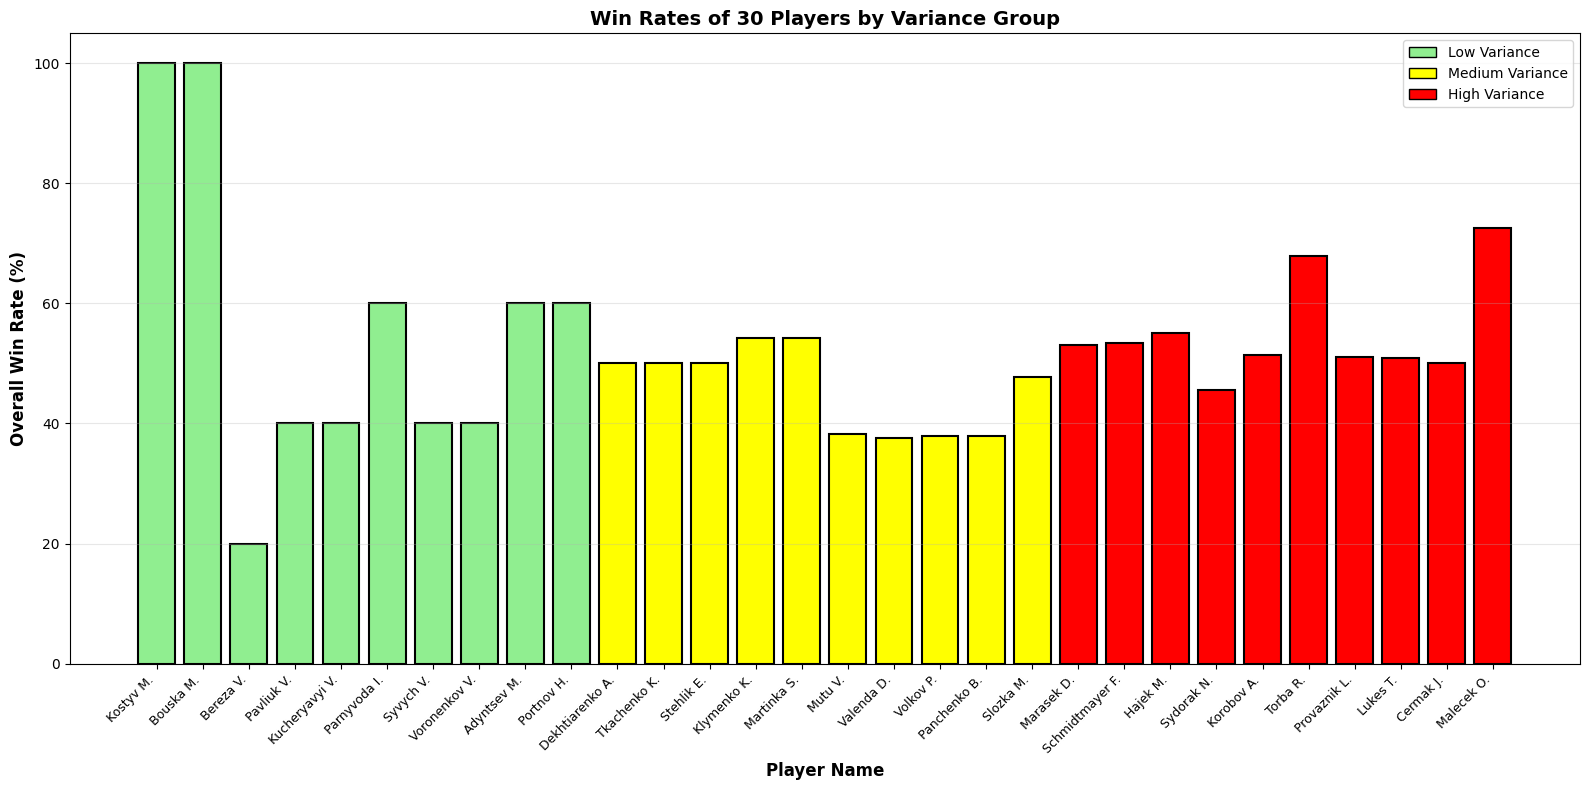

In [8]:
fig3, ax = plt.subplots(figsize=(16, 8))

selected_players_data = []

for player in low_variance_players:
    winrate = result_df[result_df['Player Name'] == player]['Overall Win Rate (%)'].values[0]
    selected_players_data.append({'Player': player, 'Win Rate': winrate, 'Group': 'Low Variance'})

for player in medium_variance_players:
    winrate = result_df[result_df['Player Name'] == player]['Overall Win Rate (%)'].values[0]
    selected_players_data.append({'Player': player, 'Win Rate': winrate, 'Group': 'Medium Variance'})

for player in high_variance_players:
    winrate = result_df[result_df['Player Name'] == player]['Overall Win Rate (%)'].values[0]
    selected_players_data.append({'Player': player, 'Win Rate': winrate, 'Group': 'High Variance'})

histogram_df = pd.DataFrame(selected_players_data)

color_map = {'Low Variance': 'lightgreen', 'Medium Variance': 'yellow', 'High Variance': 'red'}
colors = [color_map[group] for group in histogram_df['Group']]

bars = ax.bar(range(len(histogram_df)), histogram_df['Win Rate'], color=colors, edgecolor='black', linewidth=1.5)

ax.set_xticks(range(len(histogram_df)))
ax.set_xticklabels(histogram_df['Player'], rotation=45, ha='right', fontsize=9)

ax.set_xlabel('Player Name', fontsize=12, fontweight='bold')
ax.set_ylabel('Overall Win Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Win Rates of 30 Players by Variance Group', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

legend_elements = [
    Patch(facecolor='lightgreen', edgecolor='black', label='Low Variance'),
    Patch(facecolor='yellow', edgecolor='black', label='Medium Variance'),
    Patch(facecolor='red', edgecolor='black', label='High Variance')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# This histogram shows the overall win rates of 30 selected players categorized by their win rate variance groups: low, medium, and high. Each group is represented by a different color for easy identification.
# Based on this histogram, the win rate variances of each player doesn't have any correlation with their overall win rates.

In [15]:
# Create three separate tables based on variance groups

# High Variance Table (Top 10 highest variance)
high_variance_df = result_df[result_df['Player Name'].isin(high_variance_players)].copy()
high_variance_df = high_variance_df.sort_values('Win Rate Difference (%)', ascending=False).reset_index(drop=True)

print("\n" + "="*100)
print("HIGH VARIANCE PLAYERS (Top 10 Highest Win Rate Variance)")
print("="*100)
print(high_variance_df)
print("-"*100)
print(f"MEAN VALUES:")
print(f"Total Matches: {high_variance_df['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {high_variance_df['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {high_variance_df['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {high_variance_df['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {high_variance_df['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {high_variance_df['Avg Days Between Matches'].mean():.2f}")

# Medium Variance Table (Middle 10 players)
medium_variance_df = result_df[result_df['Player Name'].isin(medium_variance_players)].copy()
medium_variance_df = medium_variance_df.sort_values('Win Rate Difference (%)', ascending=False).reset_index(drop=True)

print("\n" + "="*100)
print("MEDIUM VARIANCE PLAYERS (Middle 10 Players)")
print("="*100)
print(medium_variance_df)
print("-"*100)
print(f"MEAN VALUES:")
print(f"Total Matches: {medium_variance_df['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {medium_variance_df['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {medium_variance_df['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {medium_variance_df['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {medium_variance_df['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {medium_variance_df['Avg Days Between Matches'].mean():.2f}")

# Low Variance Table (Bottom 10 lowest variance)
low_variance_df = result_df[result_df['Player Name'].isin(low_variance_players)].copy()
low_variance_df = low_variance_df.sort_values('Win Rate Difference (%)', ascending=False).reset_index(drop=True)

print("\n" + "="*100)
print("LOW VARIANCE PLAYERS (Bottom 10 Lowest Win Rate Variance)")
print("="*100)
print(low_variance_df)
print("-"*100)
print(f"MEAN VALUES:")
print(f"Total Matches: {low_variance_df['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {low_variance_df['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {low_variance_df['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {low_variance_df['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {low_variance_df['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {low_variance_df['Avg Days Between Matches'].mean():.2f}")


HIGH VARIANCE PLAYERS (Top 10 Highest Win Rate Variance)
       Player Name  Total Matches  Overall Win Rate (%)  \
0       Malecek O.             40                 72.50   
1         Torba R.             78                 67.95   
2         Hajek M.             20                 55.00   
3  Schmidtmayer F.             15                 53.33   
4       Marasek D.             32                 53.12   
5       Korobov A.             35                 51.43   
6     Provaznik L.             47                 51.06   
7         Lukes T.             53                 50.94   
8        Cermak J.             16                 50.00   
9       Sydorak N.             68                 45.59   

   Highest Daily Win Rate (%)  Lowest Daily Win Rate (%)  \
0                       100.0                        0.0   
1                       100.0                        0.0   
2                       100.0                        0.0   
3                       100.0                       

In [16]:
# Create tables with 50 players each based on variance groups

result_df_sorted_50 = result_df.sort_values('Win Rate Difference (%)')

n_players_50 = len(result_df_sorted_50)
if n_players_50 >= 150:
    low_variance_players_50 = result_df_sorted_50.head(50)['Player Name'].tolist()
    medium_variance_players_50 = result_df_sorted_50.iloc[n_players_50//2 - 25:n_players_50//2 + 25]['Player Name'].tolist()
    high_variance_players_50 = result_df_sorted_50.tail(50)['Player Name'].tolist()
else:
    n_per_group_50 = min(50, n_players_50 // 3)
    low_variance_players_50 = result_df_sorted_50.head(n_per_group_50)['Player Name'].tolist()
    medium_variance_players_50 = result_df_sorted_50.iloc[n_per_group_50:2*n_per_group_50]['Player Name'].tolist()
    high_variance_players_50 = result_df_sorted_50.tail(n_per_group_50)['Player Name'].tolist()

# High Variance Table (Top 50 highest variance)
high_variance_df_50 = result_df[result_df['Player Name'].isin(high_variance_players_50)].copy()

print("\n" + "="*100)
print("HIGH VARIANCE PLAYERS (Top 50 Highest Win Rate Variance) - MEAN VALUES")
print("="*100)
print(f"Number of Players: {len(high_variance_df_50)}")
print(f"Total Matches: {high_variance_df_50['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {high_variance_df_50['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {high_variance_df_50['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {high_variance_df_50['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {high_variance_df_50['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {high_variance_df_50['Avg Days Between Matches'].mean():.2f}")

# Medium Variance Table (Middle 50 players)
medium_variance_df_50 = result_df[result_df['Player Name'].isin(medium_variance_players_50)].copy()

print("\n" + "="*100)
print("MEDIUM VARIANCE PLAYERS (Middle 50 Players) - MEAN VALUES")
print("="*100)
print(f"Number of Players: {len(medium_variance_df_50)}")
print(f"Total Matches: {medium_variance_df_50['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {medium_variance_df_50['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {medium_variance_df_50['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {medium_variance_df_50['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {medium_variance_df_50['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {medium_variance_df_50['Avg Days Between Matches'].mean():.2f}")

# Low Variance Table (Bottom 50 lowest variance)
low_variance_df_50 = result_df[result_df['Player Name'].isin(low_variance_players_50)].copy()

print("\n" + "="*100)
print("LOW VARIANCE PLAYERS (Bottom 50 Lowest Win Rate Variance) - MEAN VALUES")
print("="*100)
print(f"Number of Players: {len(low_variance_df_50)}")
print(f"Total Matches: {low_variance_df_50['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {low_variance_df_50['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {low_variance_df_50['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {low_variance_df_50['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {low_variance_df_50['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {low_variance_df_50['Avg Days Between Matches'].mean():.2f}")


HIGH VARIANCE PLAYERS (Top 50 Highest Win Rate Variance) - MEAN VALUES
Number of Players: 50
Total Matches: 43.70
Overall Win Rate (%): 51.08
Highest Daily Win Rate (%): 100.00
Lowest Daily Win Rate (%): 0.00
Win Rate Difference (%): 100.00
Avg Days Between Matches: 0.65

MEDIUM VARIANCE PLAYERS (Middle 50 Players) - MEAN VALUES
Number of Players: 50
Total Matches: 33.28
Overall Win Rate (%): 47.30
Highest Daily Win Rate (%): 74.80
Lowest Daily Win Rate (%): 14.80
Win Rate Difference (%): 60.00
Avg Days Between Matches: 0.71

LOW VARIANCE PLAYERS (Bottom 50 Lowest Win Rate Variance) - MEAN VALUES
Number of Players: 50
Total Matches: 16.16
Overall Win Rate (%): 48.45
Highest Daily Win Rate (%): 55.30
Lowest Daily Win Rate (%): 41.80
Win Rate Difference (%): 13.50
Avg Days Between Matches: 0.89


In [21]:
# Find information about Adyntsev M.
player_name = "Pavliuk V."

# Get all matches for this player
player1_matches = df[df['Player1'] == player_name].copy()
player2_matches = df[df['Player2'] == player_name].copy()

# Combine all matches
all_matches = pd.concat([
    player1_matches[['Date', 'Day', 'Player1', 'Player2', 'HomeWinner']],
    player2_matches[['Date', 'Day', 'Player1', 'Player2', 'HomeWinner']]
])

all_matches = all_matches.sort_values('Date').reset_index(drop=True)

print(f"\n{'='*100}")
print(f"MATCH HISTORY FOR {player_name}")
print(f"{'='*100}")
print(f"Total matches played: {len(all_matches)}")

# Calculate average days between matches
if len(all_matches) > 1:
    day_differences = []
    for i in range(1, len(all_matches)):
        prev_day = all_matches.loc[i-1, 'Day']
        curr_day = all_matches.loc[i, 'Day']
        diff = (pd.to_datetime(curr_day) - pd.to_datetime(prev_day)).days
        day_differences.append(diff)
    avg_days_between_matches = np.mean(day_differences)
    print(f"Average days between matches: {avg_days_between_matches:.2f} days")
else:
    print(f"Average days between matches: N/A (only 1 match)")

print(f"\nMatch details:")
print(all_matches.to_string(index=False))

# Show when each match was played (dates only)
print(f"\n{'='*100}")
print(f"MATCH DATES FOR {player_name}")
print(f"{'='*100}")
match_dates = all_matches['Day'].unique()
print(f"Unique days played: {len(match_dates)}")
print(f"\nDates:")
for date in sorted(match_dates):
    num_matches = len(all_matches[all_matches['Day'] == date])
    print(f"{date}: {num_matches} match(es)")

# Show player stats from result_df if available
print(f"\n{'='*100}")
print(f"PLAYER STATISTICS FROM DATAFRAME")
print(f"{'='*100}")
if player_name in result_df['Player Name'].values:
    player_stats = result_df[result_df['Player Name'] == player_name]
    print(player_stats.to_string(index=False))
    print(f"\nDetailed Statistics:")
    for col in player_stats.columns:
        value = player_stats[col].values[0]
        print(f"{col}: {value}")
else:
    print(f"{player_name} not found in result_df (may have less than 10 total matches)")


MATCH HISTORY FOR Pavliuk V.
Total matches played: 10
Average days between matches: 2.67 days

Match details:
               Date        Day        Player1     Player2  HomeWinner
2022-06-11 08:40:00 2022-06-11     Pavliuk V.  Minenko A.           0
2022-06-11 10:40:00 2022-06-11     Pavliuk V.  Solomko S.           1
2022-06-11 12:10:00 2022-06-11     Pavliuk V. Semenets S.           0
2022-06-11 13:10:00 2022-06-11     Pavliuk V. Klymenko K.           0
2022-06-11 14:10:00 2022-06-11    Karpenko O.  Pavliuk V.           0
2022-07-05 14:40:00 2022-07-05     Pavliuk V.  Kovshun Y.           0
2022-07-05 16:10:00 2022-07-05 Kucheryavyi V.  Pavliuk V.           0
2022-07-05 17:10:00 2022-07-05     Pavliuk V.   Troian A.           0
2022-07-05 18:10:00 2022-07-05   Dovzhenko S.  Pavliuk V.           1
2022-07-05 20:10:00 2022-07-05     Pavliuk V. Melnykov V.           1

MATCH DATES FOR Pavliuk V.
Unique days played: 2

Dates:
2022-06-11: 5 match(es)
2022-07-05: 5 match(es)

PLAYER STATI